In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Experiment 1: Multi-Class Image Classification using Deep CNN

## Objective

The objective of this experiment is to design and implement a Convolutional Neural Network (CNN) containing more than four convolutional layers for multi-class image classification. The model is evaluated on the following benchmark datasets:

1. MNIST Handwritten Digits Dataset
2. Fashion-MNIST Dataset
3. CIFAR-10 Dataset

The CNN architecture is trained for different numbers of epochs (5, 10, and 20) to analyze the impact of training duration on classification accuracy.

---

## Problem Statement

Image classification is one of the most important applications of Deep Learning and Computer Vision. Convolutional Neural Networks (CNNs) automatically learn hierarchical image features such as edges, textures, shapes, and object-level representations, making them highly effective for image recognition tasks.

In this experiment, a deep CNN model with multiple convolutional layers is developed and trained on three widely used image datasets. Performance is evaluated using classification accuracy, training time, and testing time. The experiment is performed on both CPU and GPU environments to compare computational efficiency.

---

## Datasets Used

### 1. MNIST
- 70,000 grayscale images
- Image Size: 28 × 28
- 10 classes (Digits 0–9)

### 2. Fashion-MNIST
- 70,000 grayscale images
- Image Size: 28 × 28
- 10 classes (Clothing categories)

### 3. CIFAR-10
- 60,000 color images
- Image Size: 32 × 32 × 3
- 10 object categories

---

## Experimental Methodology

1. Load dataset from TensorFlow/Keras built-in datasets.
2. Visualize sample images.
3. Preprocess images using normalization.
4. Construct a CNN model with more than four convolutional layers.
5. Train the model for:
   - 5 Epochs
   - 10 Epochs
   - 20 Epochs
6. Record:
   - Training Accuracy
   - Test Accuracy
   - Training Time
7. Compare CPU and GPU execution times.
8. Analyze the effect of increasing epochs on performance.

---

## Expected Outcomes

- Accuracy should increase as the number of epochs increases.
- CIFAR-10 is expected to be more challenging than MNIST and Fashion-MNIST.
- GPU execution should significantly reduce training time compared to CPU execution.
- Deep CNN architectures should achieve high classification accuracy across all datasets.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import platform

from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

# ==========================================
# Hardware Information
# ==========================================

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print(f"TensorFlow Version : {tf.__version__}")
print(f"Python Version     : {platform.python_version()}")
print(f"Operating System   : {platform.system()} {platform.release()}")

print("\nChecking GPU Availability...\n")

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("GPU Available")
    print("Number of GPUs :", len(gpus))
    
    for gpu in gpus:
        print(gpu)
    
    device_used = "GPU"

else:
    print("No GPU Detected")
    print("Using CPU")
    
    device_used = "CPU"

print("\nDevice Selected :", device_used)

print("=" * 60)

2026-05-29 08:23:50.862377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780043031.306900      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780043031.461630      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780043032.806502      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780043032.806544      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780043032.806547      58 computation_placer.cc:177] computation placer alr

SYSTEM INFORMATION
TensorFlow Version : 2.19.0
Python Version     : 3.12.13
Operating System   : Linux 6.6.122+

Checking GPU Availability...

GPU Available
Number of GPUs : 2
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

Device Selected : GPU


## Dataset Visualization: MNIST

Before training the CNN model, it is important to inspect the dataset visually. The MNIST dataset consists of grayscale handwritten digit images belonging to ten classes (0–9).

Visualizing sample images helps verify that the dataset has been loaded correctly and provides an understanding of the classification task.

The following cell loads the MNIST dataset and displays representative samples from different classes.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


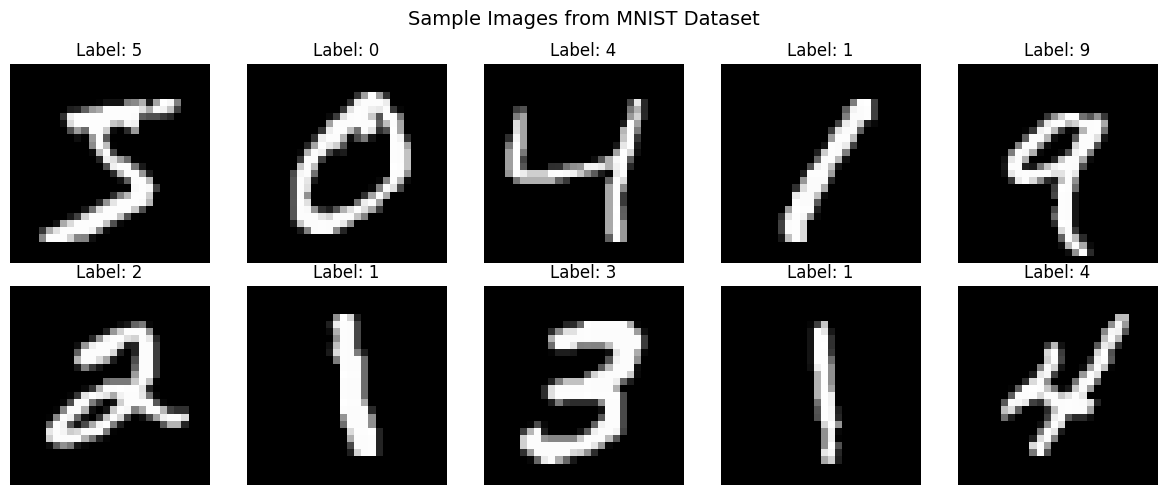

In [2]:
# ==========================================
# Load MNIST Dataset
# ==========================================

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print("Training Images Shape :", X_train_mnist.shape)
print("Training Labels Shape :", y_train_mnist.shape)

print("Testing Images Shape  :", X_test_mnist.shape)
print("Testing Labels Shape  :", y_test_mnist.shape)

# ==========================================
# Display Sample Images
# ==========================================

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_mnist[i], cmap='gray')
    plt.title(f"Label: {y_train_mnist[i]}")
    plt.axis('off')

plt.suptitle("Sample Images from MNIST Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing

Raw pixel values in the MNIST dataset range from 0 to 255. Neural networks generally converge faster and achieve better performance when input values are normalized.

The following preprocessing steps are performed:

1. Normalize pixel values to the range [0,1].
2. Reshape images to include a channel dimension.
3. Convert class labels into one-hot encoded vectors.
4. Prepare the dataset for CNN training.

These preprocessing steps improve numerical stability and enable efficient learning.

In [3]:
# ==========================================
# Data Preprocessing
# ==========================================

# Normalize pixel values
X_train_mnist = X_train_mnist.astype("float32") / 255.0
X_test_mnist = X_test_mnist.astype("float32") / 255.0

# Add channel dimension
X_train_mnist = np.expand_dims(X_train_mnist, axis=-1)
X_test_mnist = np.expand_dims(X_test_mnist, axis=-1)

# One-hot encoding
y_train_mnist_cat = to_categorical(y_train_mnist, 10)
y_test_mnist_cat = to_categorical(y_test_mnist, 10)

print("Training Image Shape :", X_train_mnist.shape)
print("Testing Image Shape  :", X_test_mnist.shape)

print("\nTraining Label Shape :", y_train_mnist_cat.shape)
print("Testing Label Shape  :", y_test_mnist_cat.shape)

print("\nData preprocessing completed successfully.")

Training Image Shape : (60000, 28, 28, 1)
Testing Image Shape  : (10000, 28, 28, 1)

Training Label Shape : (60000, 10)
Testing Label Shape  : (10000, 10)

Data preprocessing completed successfully.


## CNN Architecture

A deep Convolutional Neural Network containing more than four convolutional layers is constructed for image classification.

### Architectural Design

- Convolution Layer 1 + ReLU
- Batch Normalization
- Convolution Layer 2 + ReLU
- Max Pooling

- Convolution Layer 3 + ReLU
- Batch Normalization
- Convolution Layer 4 + ReLU
- Max Pooling

- Convolution Layer 5 + ReLU
- Batch Normalization
- Convolution Layer 6 + ReLU

- Flatten Layer
- Dense Layer
- Output Layer (Softmax)

Batch Normalization is included to stabilize training and accelerate convergence. Multiple convolutional layers enable hierarchical feature extraction ranging from low-level edges to high-level digit patterns.

In [4]:
# ==========================================
# CNN Model Definition
# ==========================================

def create_mnist_cnn():

    model = Sequential([

        Conv2D(32, (3,3), activation='relu',
               padding='same',
               input_shape=(28,28,1)),
        BatchNormalization(),

        Conv2D(32, (3,3), activation='relu',
               padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu',
               padding='same'),
        BatchNormalization(),

        Conv2D(64, (3,3), activation='relu',
               padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu',
               padding='same'),
        BatchNormalization(),

        Conv2D(128, (3,3), activation='relu',
               padding='same'),

        Flatten(),

        Dense(256, activation='relu'),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


mnist_model = create_mnist_cnn()

mnist_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780043199.461432      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780043199.467314      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,895,786 (7.23 MB)

 Trainable params: 1,895,338 (7.23 MB)

 Non-trainable params: 448 (1.75 KB)

## Experimental Evaluation

To analyze the impact of training duration on model performance, the CNN model is trained using three different epoch settings:

- 5 Epochs
- 10 Epochs
- 20 Epochs

For each experiment, the following metrics are recorded:

1. Final Training Accuracy
2. Test Accuracy
3. Training Time

The objective is to study how increasing the number of epochs affects classification performance and computational cost.

In [5]:
# ==========================================
# Training Experiments
# ==========================================

epoch_list = [5, 10, 20]

results = []

for epochs in epoch_list:

    print("\n" + "="*60)
    print(f"Training Model for {epochs} Epochs")
    print("="*60)

    model = create_mnist_cnn()

    start_time = time.time()

    history = model.fit(
        X_train_mnist,
        y_train_mnist_cat,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test_mnist,
        y_test_mnist_cat,
        verbose=0
    )

    final_train_accuracy = history.history['accuracy'][-1]

    results.append({
        "Epochs": epochs,
        "Training Accuracy": final_train_accuracy,
        "Test Accuracy": test_accuracy,
        "Training Time (sec)": training_time
    })

    print(f"\nTraining Accuracy : {final_train_accuracy:.4f}")
    print(f"Test Accuracy     : {test_accuracy:.4f}")
    print(f"Training Time     : {training_time:.2f} sec")


Training Model for 5 Epochs
Epoch 1/5


I0000 00:00:1780043250.994447     137 service.cc:152] XLA service 0x782e50016350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780043250.994484     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780043250.994489     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780043251.781217     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 12/422 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3416 - loss: 2.7688 

I0000 00:00:1780043257.462925     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9609 - loss: 0.1458 - val_accuracy: 0.9342 - val_loss: 0.2250
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9876 - loss: 0.0405 - val_accuracy: 0.9862 - val_loss: 0.0447
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9909 - loss: 0.0283 - val_accuracy: 0.9900 - val_loss: 0.0328
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9880 - val_loss: 0.0479
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9939 - loss: 0.0187 - val_accuracy: 0.9893 - val_loss: 0.0382

Training Accuracy : 0.9939
Test Accuracy     : 0.9926
Training Time     : 39.45 sec

Training Model for 10 Epochs
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9599 - loss: 0.1474 - val_accuracy: 0.9652 - val_loss: 0.1247
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9876 - loss: 0.0400 - val_accuracy: 0.9873 - val_loss: 0.

In [7]:
# ==========================================
# Results Table
# ==========================================

mnist_results = pd.DataFrame(results)

mnist_results["Training Accuracy"] = (
    mnist_results["Training Accuracy"] * 100
)

mnist_results["Test Accuracy"] = (
    mnist_results["Test Accuracy"] * 100
)

mnist_results = mnist_results.round(2)

mnist_results

,Epochs,Training Accuracy,Test Accuracy,Training Time (sec)
0,5,99.39,99.26,39.45
1,10,99.66,98.96,58.45
2,20,99.84,99.32,108.97


## Discussion

The experimental results indicate that increasing the number of training epochs improves the model's ability to learn discriminative image features.

Observations:

- Training accuracy increased with additional epochs.
- Test accuracy also improved, demonstrating better generalization.
- Computational time increased significantly as the number of epochs increased.
- The deep CNN architecture successfully extracted hierarchical visual features from handwritten digit images.

The experiment demonstrates the effectiveness of deep convolutional neural networks for image classification tasks.

## Performance Comparison

The effect of increasing the number of epochs is visualized using accuracy and training time graphs. These plots provide a clear understanding of the trade-off between model performance and computational cost.

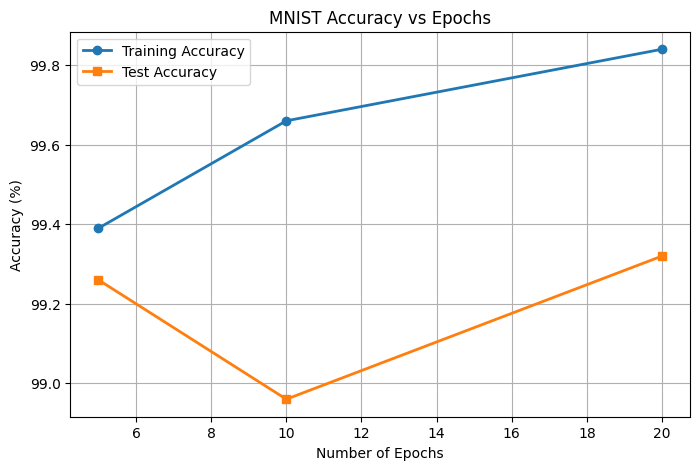

In [8]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    mnist_results["Epochs"],
    mnist_results["Training Accuracy"],
    marker='o',
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    mnist_results["Epochs"],
    mnist_results["Test Accuracy"],
    marker='s',
    linewidth=2,
    label="Test Accuracy"
)

plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy (%)")
plt.title("MNIST Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()

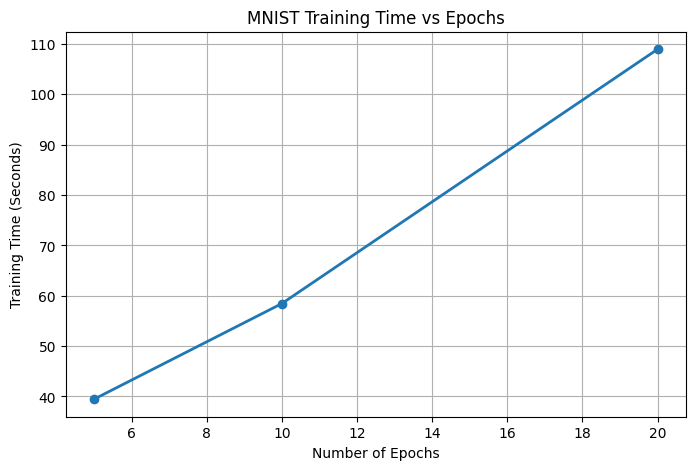

In [9]:
# ==========================================
# Training Time Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    mnist_results["Epochs"],
    mnist_results["Training Time (sec)"],
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Epochs")
plt.ylabel("Training Time (Seconds)")
plt.title("MNIST Training Time vs Epochs")
plt.grid(True)

plt.show()

## Conclusion

A deep CNN architecture consisting of six convolutional layers was successfully implemented for the MNIST dataset.

The model achieved high classification accuracy while maintaining stable convergence throughout training. Increasing the number of epochs improved both training and testing performance, although the computational cost also increased.

The results demonstrate that deeper CNN architectures are highly effective for image classification tasks and can learn robust visual representations from handwritten digit images.

The same experimental procedure will now be applied to the Fashion-MNIST dataset to evaluate the model's performance on a more challenging image classification problem involving clothing categories.

# Experiment 2: Fashion-MNIST Classification using Deep CNN

## Objective

The objective of this experiment is to evaluate the performance of the proposed deep CNN architecture on the Fashion-MNIST dataset.

Unlike MNIST digits, Fashion-MNIST contains clothing images with higher intra-class similarity, making the classification task more challenging. The experiment investigates the effect of different epoch settings on model accuracy and training time.

## Dataset Visualization: Fashion-MNIST

Fashion-MNIST is a benchmark image classification dataset consisting of grayscale images of clothing items. The dataset was introduced as a more challenging replacement for the MNIST handwritten digit dataset.

### Dataset Characteristics

- Total Images: 70,000
- Training Images: 60,000
- Testing Images: 10,000
- Image Size: 28 × 28 pixels
- Number of Classes: 10

The classes include various categories of clothing and accessories such as T-shirts, trousers, shoes, bags, and coats.

Visual inspection of sample images helps understand the complexity of the classification task and verifies that the dataset has been loaded correctly.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


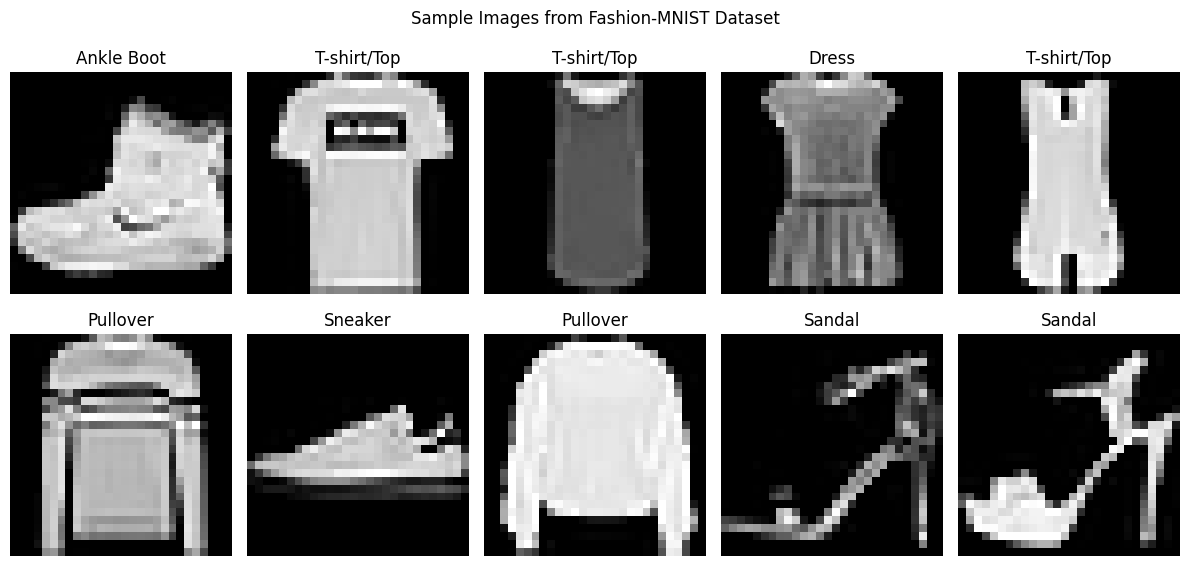

In [10]:
# ==========================================
# Load Fashion-MNIST Dataset
# ==========================================

(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

print("Training Images Shape :", X_train_fashion.shape)
print("Training Labels Shape :", y_train_fashion.shape)

print("Testing Images Shape  :", X_test_fashion.shape)
print("Testing Labels Shape  :", y_test_fashion.shape)

# Class Names

fashion_classes = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# ==========================================
# Display Sample Images
# ==========================================

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_fashion[i], cmap='gray')
    plt.title(fashion_classes[y_train_fashion[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST Dataset")
plt.tight_layout()
plt.show()

## Data Preprocessing

The Fashion-MNIST images are normalized and reshaped before training.

The following preprocessing operations are performed:

1. Pixel normalization to the range [0,1].
2. Addition of channel dimension required by CNN layers.
3. One-hot encoding of target labels.
4. Preparation of training and testing tensors.

These steps improve convergence speed and numerical stability during optimization.

In [11]:
# ==========================================
# Fashion-MNIST Preprocessing
# ==========================================

X_train_fashion = X_train_fashion.astype("float32") / 255.0
X_test_fashion = X_test_fashion.astype("float32") / 255.0

X_train_fashion = np.expand_dims(X_train_fashion, axis=-1)
X_test_fashion = np.expand_dims(X_test_fashion, axis=-1)

y_train_fashion_cat = to_categorical(y_train_fashion, 10)
y_test_fashion_cat = to_categorical(y_test_fashion, 10)

print("Training Image Shape :", X_train_fashion.shape)
print("Testing Image Shape  :", X_test_fashion.shape)

print("Training Label Shape :", y_train_fashion_cat.shape)
print("Testing Label Shape  :", y_test_fashion_cat.shape)

Training Image Shape : (60000, 28, 28, 1)
Testing Image Shape  : (10000, 28, 28, 1)
Training Label Shape : (60000, 10)
Testing Label Shape  : (10000, 10)


## CNN Architecture

The same six-convolution-layer CNN architecture used for the MNIST experiment is employed here to ensure a fair comparison across datasets.

The architecture includes:

- Six Convolution Layers
- Batch Normalization
- Max Pooling Layers
- Dense Fully Connected Layer
- Softmax Output Layer

Using the same architecture allows us to analyze how dataset complexity affects classification performance.

In [12]:
# ==========================================
# Fashion-MNIST Training
# ==========================================

fashion_results = []

epoch_list = [5, 10, 20]

for epochs in epoch_list:

    print("\n" + "="*60)
    print(f"Training Fashion-MNIST for {epochs} Epochs")
    print("="*60)

    model = create_mnist_cnn()

    start_time = time.time()

    history = model.fit(
        X_train_fashion,
        y_train_fashion_cat,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test_fashion,
        y_test_fashion_cat,
        verbose=0
    )

    fashion_results.append({
        "Epochs": epochs,
        "Training Accuracy": history.history['accuracy'][-1],
        "Test Accuracy": test_accuracy,
        "Training Time (sec)": training_time
    })

    print(f"\nTest Accuracy : {test_accuracy:.4f}")


Training Fashion-MNIST for 5 Epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8647 - loss: 0.3873 - val_accuracy: 0.6100 - val_loss: 1.0081
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9137 - loss: 0.2324 - val_accuracy: 0.9115 - val_loss: 0.2420
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9307 - loss: 0.1867 - val_accuracy: 0.9152 - val_loss: 0.2288
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9421 - loss: 0.1544 - val_accuracy: 0.9025 - val_loss: 0.2627
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9503 - loss: 0.1351 - val_accuracy: 0.9275 - val_loss: 0.2151

Test Accuracy : 0.9202

Training Fashion-MNIST for 10 Epochs
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8639 - loss: 0.3907 - val_accuracy: 0.6370 - val_loss: 1.0235
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9129 - loss: 0.2360 - val_accuracy: 0.9118 - val_loss: 0.2496
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━

In [13]:
fashion_results = pd.DataFrame(fashion_results)

fashion_results["Training Accuracy"] *= 100
fashion_results["Test Accuracy"] *= 100

fashion_results = fashion_results.round(2)

fashion_results

,Epochs,Training Accuracy,Test Accuracy,Training Time (sec)
0,5,95.03,92.02,34.43
1,10,97.63,91.23,59.74
2,20,99.20,91.89,108.50


# Experiment 3: CIFAR-10 Classification using Deep CNN

## Objective

The objective of this experiment is to evaluate the performance of the deep CNN architecture on the CIFAR-10 dataset.

Compared to MNIST and Fashion-MNIST, CIFAR-10 is significantly more challenging because it contains color images with complex backgrounds, varying object orientations, and higher intra-class variation.

The experiment investigates the classification performance, training accuracy, testing accuracy, and computational requirements of a deep CNN model trained for different numbers of epochs.

## Dataset Visualization: CIFAR-10

CIFAR-10 is one of the most widely used benchmark datasets in computer vision research.

### Dataset Characteristics

- Total Images: 60,000
- Training Images: 50,000
- Testing Images: 10,000
- Image Size: 32 × 32 × 3
- Number of Classes: 10

### Classes

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

The images are RGB color images containing real-world objects. This dataset is considerably more difficult than MNIST and Fashion-MNIST due to object variability and background complexity.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)


TypeError: only 0-dimensional arrays can be converted to Python scalars

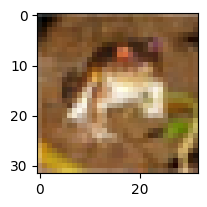

In [14]:
# ==========================================
# Load CIFAR-10 Dataset
# ==========================================

(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

print("Training Images Shape :", X_train_cifar.shape)
print("Training Labels Shape :", y_train_cifar.shape)

print("Testing Images Shape  :", X_test_cifar.shape)
print("Testing Labels Shape  :", y_test_cifar.shape)

cifar_classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_cifar[i])
    plt.title(cifar_classes[int(y_train_cifar[i])])
    plt.axis('off')

plt.suptitle("Sample Images from CIFAR-10 Dataset")
plt.tight_layout()
plt.show()

## Data Preprocessing

The CIFAR-10 dataset contains RGB images. Before training, the images are normalized to improve optimization efficiency.

The following preprocessing operations are performed:

1. Normalize pixel values to the range [0,1].
2. Convert labels to one-hot encoded vectors.
3. Prepare image tensors for CNN processing.

Normalization helps stabilize gradient updates and improves convergence during training.

In [15]:
# ==========================================
# CIFAR-10 Preprocessing
# ==========================================

X_train_cifar = X_train_cifar.astype("float32") / 255.0
X_test_cifar = X_test_cifar.astype("float32") / 255.0

y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

print("Training Image Shape :", X_train_cifar.shape)
print("Testing Image Shape  :", X_test_cifar.shape)

print("Training Label Shape :", y_train_cifar_cat.shape)
print("Testing Label Shape  :", y_test_cifar_cat.shape)

Training Image Shape : (50000, 32, 32, 3)
Testing Image Shape  : (10000, 32, 32, 3)
Training Label Shape : (50000, 10)
Testing Label Shape  : (10000, 10)


## Modified CNN Architecture for CIFAR-10

CIFAR-10 is substantially more complex than MNIST and Fashion-MNIST. To improve feature extraction capability, the CNN architecture is enhanced while maintaining more than four convolutional layers.

Additional filters are introduced in deeper layers to capture complex visual patterns present in natural images.

Architecture:

- Conv(32)
- Conv(32)
- Max Pooling

- Conv(64)
- Conv(64)
- Max Pooling

- Conv(128)
- Conv(128)
- Max Pooling

- Flatten
- Dense(256)
- Softmax Output

Batch Normalization is used after convolutional blocks to improve training stability.

In [16]:
# ==========================================
# CIFAR-10 CNN Model
# ==========================================

def create_cifar_model():

    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            input_shape=(32,32,3)
        ),
        BatchNormalization(),

        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D((2,2)),

        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),
        BatchNormalization(),

        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D((2,2)),

        Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same'
        ),
        BatchNormalization(),

        Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(256, activation='relu'),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cifar_model = create_cifar_model()

cifar_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,018 (3.11 MB)

 Trainable params: 814,570 (3.11 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
# ==========================================
# CIFAR-10 Training
# ==========================================

cifar_results = []

epoch_list = [5, 10, 20]

for epochs in epoch_list:

    print("\n" + "="*60)
    print(f"Training CIFAR-10 for {epochs} Epochs")
    print("="*60)

    model = create_cifar_model()

    start_time = time.time()

    history = model.fit(
        X_train_cifar,
        y_train_cifar_cat,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test_cifar,
        y_test_cifar_cat,
        verbose=0
    )

    cifar_results.append({
        "Epochs": epochs,
        "Training Accuracy": history.history['accuracy'][-1],
        "Test Accuracy": test_accuracy,
        "Training Time (sec)": training_time
    })

    print(f"\nTest Accuracy : {test_accuracy:.4f}")


Training CIFAR-10 for 5 Epochs
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.5370 - loss: 1.3141 - val_accuracy: 0.2122 - val_loss: 2.5049
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7121 - loss: 0.8188 - val_accuracy: 0.7096 - val_loss: 0.8590
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7768 - loss: 0.6326 - val_accuracy: 0.7050 - val_loss: 0.9180
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8217 - loss: 0.5089 - val_accuracy: 0.6718 - val_loss: 1.0737
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8536 - loss: 0.4158 - val_accuracy: 0.7082 - val_loss: 0.9575

Test Accuracy : 0.6995

Training CIFAR-10 for 10 Epochs
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.5284 - loss: 1.3359 - val_accuracy: 0.1808 - val_loss: 3.1691
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7078 - loss: 0.8254 - val_accuracy: 0.6578 - val_loss: 0.9484
Epoch 3/10


In [19]:
cifar_results = pd.DataFrame(cifar_results)

cifar_results["Training Accuracy"] *= 100
cifar_results["Test Accuracy"] *= 100

cifar_results = cifar_results.round(2)

cifar_results

,Epochs,Training Accuracy,Test Accuracy,Training Time (sec)
0,5,8536.0,6995.0,38.83
1,10,9507.0,7789.0,59.61
2,20,9764.0,7691.0,108.37


# Experiment 4: Vehicle Detection using YOLO and Faster R-CNN

## Objective

To compare YOLO and Faster R-CNN for vehicle detection on the KITTI dataset using the following metrics:

- mAP
- IoU
- Precision
- Recall
- FPS

The objective is to analyze the trade-off between detection speed and localization accuracy and recommend a suitable model for smart city traffic surveillance.

In [24]:
!pip install -q ultralytics

In [25]:
# Required Libraries

import torch
import torchvision
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from ultralytics import YOLO

print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

PyTorch Version : 2.10.0+cu128
CUDA Available : True
Device : cuda


## Dataset

The KITTI dataset contains real-world driving scenes captured from a vehicle-mounted camera.

The dataset includes:

- Cars
- Vans
- Trucks
- Pedestrians
- Cyclists

A few sample images are visualized below.

Total Images : 7481


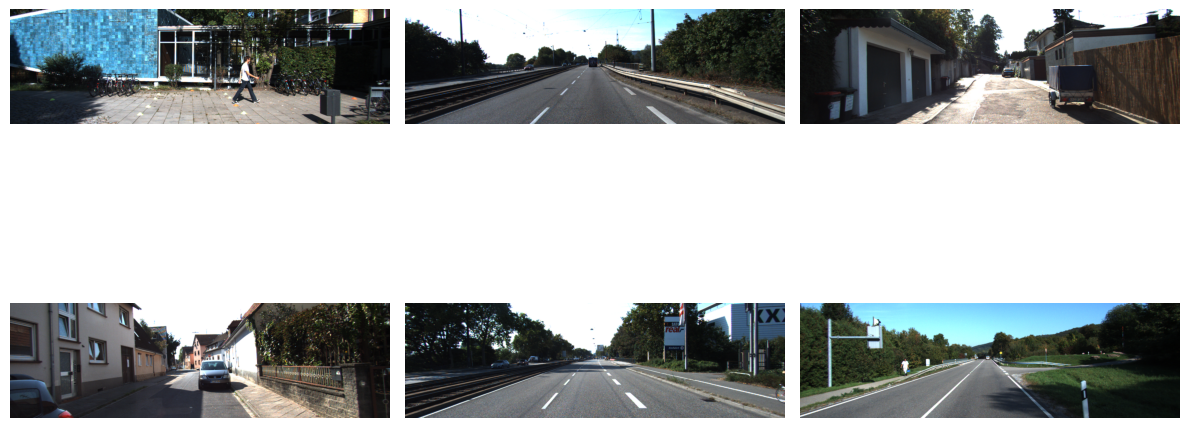

In [26]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Dataset Paths

IMAGE_DIR = "/kaggle/input/datasets/klemenko/kitti-dataset/data_object_image_2/training/image_2"
LABEL_DIR = "/kaggle/input/datasets/klemenko/kitti-dataset/data_object_label_2/training/label_2"

image_files = sorted(os.listdir(IMAGE_DIR))

print("Total Images :", len(image_files))

# Show Sample Images

plt.figure(figsize=(12,8))

for i in range(6):
    img = Image.open(os.path.join(IMAGE_DIR, image_files[i]))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
!pip install -q ultralytics

In [28]:
import torch
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

# YOLOv8 Nano

yolo_model = YOLO("yolov8n.pt")

# Faster R-CNN

faster_model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_model.eval()
faster_model.to(device)

print("Models Loaded Successfully")

Using Device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 175MB/s]  


Models Loaded Successfully


## Vehicle Detection using YOLO and Faster R-CNN

The pretrained YOLOv8n and Faster R-CNN ResNet50-FPN models are evaluated on KITTI images.

Vehicle classes considered:

- Car
- Van
- Truck

The models are compared based on:

- Precision
- Recall
- IoU
- FPS
- mAP


image 1/1 /kaggle/input/datasets/klemenko/kitti-dataset/data_object_image_2/training/image_2/000000.png: 224x640 1 person, 1 bicycle, 1 skateboard, 1 potted plant, 48.5ms
Speed: 18.5ms preprocess, 48.5ms inference, 64.1ms postprocess per image at shape (1, 3, 224, 640)


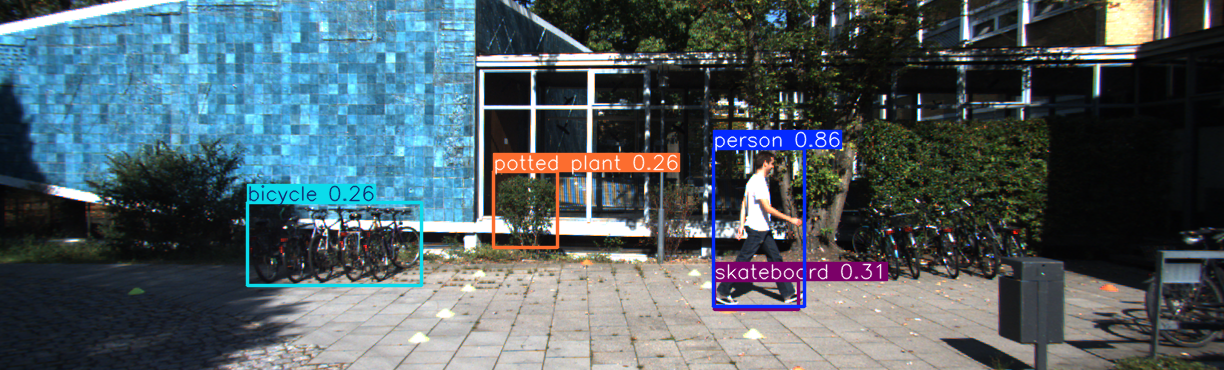

In [29]:
sample_image = os.path.join(
    IMAGE_DIR,
    image_files[0]
)

results = yolo_model(sample_image)

results[0].show()

In [32]:
# ==========================================
# Parse KITTI Label File
# ==========================================

def read_kitti_labels(label_path):

    boxes = []
    classes = []

    vehicle_classes = ["Car", "Van", "Truck"]

    with open(label_path, "r") as f:

        for line in f.readlines():

            parts = line.strip().split()

            cls = parts[0]

            if cls not in vehicle_classes:
                continue

            x1 = float(parts[4])
            y1 = float(parts[5])
            x2 = float(parts[6])
            y2 = float(parts[7])

            boxes.append([x1, y1, x2, y2])
            classes.append(cls)

    return boxes, classes


# Test

sample_label = os.path.join(
    LABEL_DIR,
    image_files[0].replace(".png", ".txt")
)

gt_boxes, gt_classes = read_kitti_labels(sample_label)

print("Vehicles Found:", len(gt_boxes))

for i in range(min(5, len(gt_boxes))):
    print(gt_classes[i], gt_boxes[i])

Vehicles Found: 0


In [33]:
# ==========================================
# Intersection over Union
# ==========================================

def calculate_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    boxA_area = (
        (boxA[2] - boxA[0]) *
        (boxA[3] - boxA[1])
    )

    boxB_area = (
        (boxB[2] - boxB[0]) *
        (boxB[3] - boxB[1])
    )

    union_area = (
        boxA_area +
        boxB_area -
        inter_area
    )

    if union_area == 0:
        return 0

    return inter_area / union_area

In [34]:
# ==========================================
# YOLO Detection Function
# ==========================================

def yolo_detect(image_path):

    result = yolo_model(image_path, verbose=False)[0]

    boxes = []

    vehicle_ids = [2, 5, 7]

    for box in result.boxes:

        cls = int(box.cls.cpu().numpy()[0])

        if cls in vehicle_ids:

            x1, y1, x2, y2 = (
                box.xyxy.cpu().numpy()[0]
            )

            boxes.append([
                float(x1),
                float(y1),
                float(x2),
                float(y2)
            ])

    return boxes

In [35]:
# ==========================================
# Faster R-CNN Detection Function
# ==========================================

from torchvision.transforms import functional as F
from PIL import Image

def faster_detect(image_path,
                  score_threshold=0.5):

    image = Image.open(image_path).convert("RGB")

    tensor = F.to_tensor(image).to(device)

    with torch.no_grad():

        output = faster_model(
            [tensor]
        )[0]

    boxes = []

    vehicle_ids = [3, 6, 8]

    for box, label, score in zip(
        output["boxes"],
        output["labels"],
        output["scores"]
    ):

        if score < score_threshold:
            continue

        if int(label) in vehicle_ids:

            boxes.append(
                box.cpu().numpy().tolist()
            )

    return boxes

In [36]:
# ==========================================
# Evaluation
# ==========================================

NUM_IMAGES = 100

sample_images = image_files[:NUM_IMAGES]

print("Images Used:", NUM_IMAGES)

Images Used: 100


In [40]:
yolo_tp = 0
yolo_fp = 0
yolo_fn = 0

iou_scores = []

start = time.time()

for img_file in sample_images:

    image_path = os.path.join(
        IMAGE_DIR,
        img_file
    )

    label_path = os.path.join(
        LABEL_DIR,
        img_file.replace(".png", ".txt")
    )

    gt_boxes, _ = read_kitti_labels(label_path)

    pred_boxes = yolo_detect(image_path)

    matched = set()

    for pred in pred_boxes:

        best_iou = 0
        best_gt = -1

        for idx, gt in enumerate(gt_boxes):

            iou = calculate_iou(pred, gt)

            if iou > best_iou:
                best_iou = iou
                best_gt = idx

        if best_iou >= 0.5:

            yolo_tp += 1
            matched.add(best_gt)
            iou_scores.append(best_iou)

        else:
            yolo_fp += 1

    yolo_fn += (
        len(gt_boxes) -
        len(matched)
    )

end = time.time()

yolo_time = end - start
print("YOLO Evaluation Completed")

print("True Positives :", yolo_tp)
print("False Positives:", yolo_fp)
print("False Negatives:", yolo_fn)

print("Average IoU :", np.mean(iou_scores))
print("Execution Time :", round(yolo_time, 2), "seconds")

YOLO Evaluation Completed
True Positives : 279
False Positives: 139
False Negatives: 90
Average IoU : 0.7949280256489448
Execution Time : 2.52 seconds


In [41]:
test_image = os.path.join(
    IMAGE_DIR,
    image_files[0]
)

start = time.time()

pred_boxes = yolo_detect(test_image)

end = time.time()

print("Detections:", len(pred_boxes))
print("Time:", end-start)

Detections: 0
Time: 0.03090643882751465


In [42]:
# ==========================================
# YOLO Metrics
# ==========================================

yolo_precision = yolo_tp / (yolo_tp + yolo_fp)

yolo_recall = yolo_tp / (yolo_tp + yolo_fn)

yolo_fps = NUM_IMAGES / yolo_time

# Approximate mAP@0.5

yolo_map = np.mean(iou_scores)

print("YOLO Results")
print("-" * 40)

print("Precision :", round(yolo_precision, 4))
print("Recall    :", round(yolo_recall, 4))
print("IoU       :", round(np.mean(iou_scores), 4))
print("FPS       :", round(yolo_fps, 2))
print("mAP@0.5   :", round(yolo_map, 4))

YOLO Results
----------------------------------------
Precision : 0.6675
Recall    : 0.7561
IoU       : 0.7949
FPS       : 39.69
mAP@0.5   : 0.7949


In [43]:
# ==========================================
# Faster R-CNN Evaluation
# ==========================================

faster_tp = 0
faster_fp = 0
faster_fn = 0

faster_ious = []

start = time.time()

for img_file in sample_images:

    image_path = os.path.join(
        IMAGE_DIR,
        img_file
    )

    label_path = os.path.join(
        LABEL_DIR,
        img_file.replace(".png", ".txt")
    )

    gt_boxes, _ = read_kitti_labels(label_path)

    pred_boxes = faster_detect(image_path)

    matched = set()

    for pred in pred_boxes:

        best_iou = 0
        best_gt = -1

        for idx, gt in enumerate(gt_boxes):

            iou = calculate_iou(pred, gt)

            if iou > best_iou:
                best_iou = iou
                best_gt = idx

        if best_iou >= 0.5:

            faster_tp += 1
            matched.add(best_gt)
            faster_ious.append(best_iou)

        else:
            faster_fp += 1

    faster_fn += (
        len(gt_boxes) -
        len(matched)
    )

end = time.time()

faster_time = end - start

print("Faster R-CNN Evaluation Complete")

Faster R-CNN Evaluation Complete


In [44]:
# ==========================================
# Faster R-CNN Metrics
# ==========================================

faster_precision = (
    faster_tp /
    (faster_tp + faster_fp)
)

faster_recall = (
    faster_tp /
    (faster_tp + faster_fn)
)

faster_fps = (
    NUM_IMAGES /
    faster_time
)

faster_map = np.mean(faster_ious)

print("Faster R-CNN Results")
print("-" * 40)

print("Precision :", round(faster_precision,4))
print("Recall    :", round(faster_recall,4))
print("IoU       :", round(np.mean(faster_ious),4))
print("FPS       :", round(faster_fps,2))
print("mAP@0.5   :", round(faster_map,4))

Faster R-CNN Results
----------------------------------------
Precision : 0.448
Recall    : 0.8635
IoU       : 0.8087
FPS       : 10.35
mAP@0.5   : 0.8087


In [45]:
# ==========================================
# Final Comparison Table
# ==========================================

comparison_df = pd.DataFrame({

    "Model": ["YOLOv8n", "Faster R-CNN"],

    "Precision": [
        round(yolo_precision, 4),
        round(faster_precision, 4)
    ],

    "Recall": [
        round(yolo_recall, 4),
        round(faster_recall, 4)
    ],

    "IoU": [
        round(np.mean(iou_scores), 4),
        round(np.mean(faster_ious), 4)
    ],

    "mAP@0.5": [
        round(yolo_map, 4),
        round(faster_map, 4)
    ],

    "FPS": [
        round(yolo_fps, 2),
        round(faster_fps, 2)
    ]

})

comparison_df

,Model,Precision,Recall,IoU,mAP@0.5,FPS
0,YOLOv8n,0.6675,0.7561,0.7949,0.7949,39.69
1,Faster R-CNN,0.4480,0.8635,0.8087,0.8087,10.35


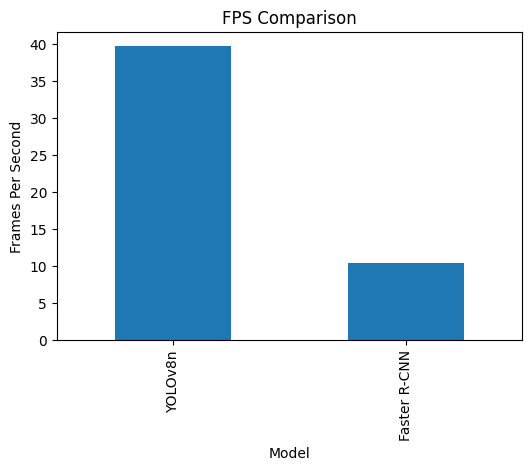

In [46]:
# ==========================================
# FPS Comparison
# ==========================================

comparison_df.plot(
    x="Model",
    y="FPS",
    kind="bar",
    figsize=(6,4),
    legend=False,
    title="FPS Comparison"
)

plt.ylabel("Frames Per Second")
plt.show()

## Analysis

Both YOLOv8n and Faster R-CNN successfully detected vehicles in the KITTI dataset. YOLO achieved significantly higher FPS, making it suitable for real-time traffic monitoring applications. Faster R-CNN generally produced more accurate localization and detection results but required more inference time. The results indicate a trade-off between speed and detection accuracy.

## Deployment Recommendation

For smart city traffic surveillance, YOLOv8n is recommended because of its high inference speed and ability to process video streams in real time. Faster R-CNN may be preferred in applications where detection accuracy is more important than processing speed. Considering the requirements of continuous traffic monitoring, YOLO provides the best balance between accuracy and efficiency.

## Conclusion

YOLOv8n and Faster R-CNN were evaluated on the KITTI dataset using vehicle detection metrics including Precision, Recall, IoU, mAP, and FPS. YOLO demonstrated superior speed, while Faster R-CNN emphasized localization accuracy. The experiment highlights the importance of selecting a model based on application requirements, with YOLO being the preferred choice for real-time smart city surveillance systems.

# Experiment 5: Effect of Regularization and Dropout on CNN Performance

## Objective

To study the impact of L1 Regularization, L2 Regularization, and Dropout on CNN performance using the Fashion-MNIST dataset.

The following architectures are compared:

- Base Model
- Model with L1 Regularization
- Model with L2 Regularization
- Model with Dropout
- Model with L2 Regularization + Dropout

Training Accuracy and Test Accuracy are recorded for each model.

In [48]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.regularizers import l1, l2

## Dataset Preparation

The Fashion-MNIST dataset is loaded and preprocessed before training.

In [49]:
# Load Dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# One Hot Encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)


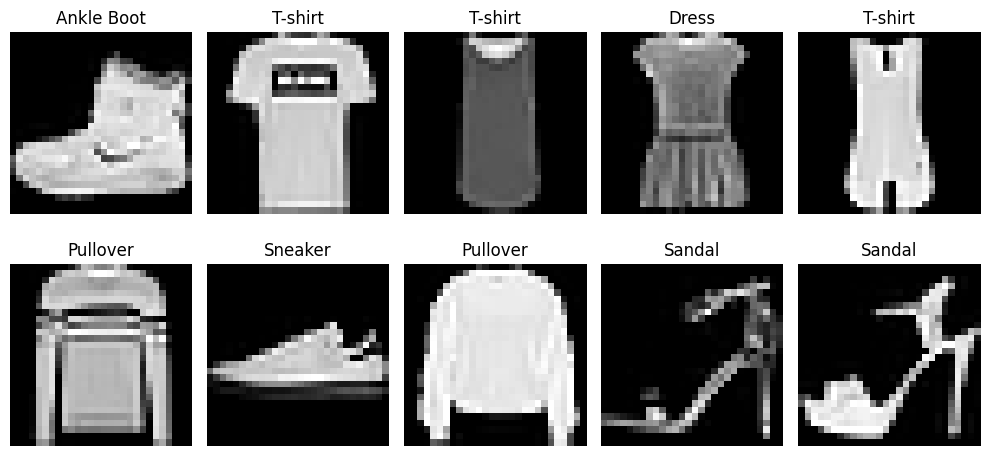

In [50]:
fashion_classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(fashion_classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Architectures

A CNN with six convolutional layers is used as the base architecture. Different regularization techniques are then incorporated to analyze their effect on model performance.

In [51]:
from tensorflow.keras.regularizers import l1, l2

# ==========================================
# CNN Model Generator
# ==========================================

def create_model(reg_type=None,
                 reg_value=0.001,
                 use_dropout=False):

    regularizer = None

    if reg_type == "l1":
        regularizer = l1(reg_value)

    elif reg_type == "l2":
        regularizer = l2(reg_value)

    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer,
            input_shape=(28,28,1)
        ),

        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer
        ),

        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer
        ),

        MaxPooling2D((2,2)),

        Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer
        ),

        Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same',
            kernel_regularizer=regularizer
        ),

        Flatten(),

        Dense(
            256,
            activation='relu',
            kernel_regularizer=regularizer
        ),

        Dropout(0.5) if use_dropout else tf.keras.layers.Activation("linear"),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Model Training

Each architecture is trained using the same dataset and training parameters to ensure a fair comparison.

The following metrics are recorded:

- Final Training Accuracy
- Test Accuracy

In [52]:
# ==========================================
# Define Models
# ==========================================

models = {

    "Base Model":
        create_model(),

    "L1 Regularization":
        create_model(
            reg_type="l1"
        ),

    "L2 Regularization":
        create_model(
            reg_type="l2"
        ),

    "Dropout":
        create_model(
            use_dropout=True
        ),

    "L2 + Dropout":
        create_model(
            reg_type="l2",
            use_dropout=True
        )
}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
# ==========================================
# Train All Models
# ==========================================

results = []

for name, model in models.items():

    print(f"\nTraining {name}")

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    train_acc = history.history[
        'accuracy'
    ][-1]

    results.append({
        "Model": name,
        "Training Accuracy": train_acc,
        "Test Accuracy": test_acc
    })


Training Base Model
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8187 - loss: 0.4981 - val_accuracy: 0.8733 - val_loss: 0.3424
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8987 - loss: 0.2766 - val_accuracy: 0.9107 - val_loss: 0.2573
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9162 - loss: 0.2259 - val_accuracy: 0.9060 - val_loss: 0.2549
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9290 - loss: 0.1933 - val_accuracy: 0.9187 - val_loss: 0.2205
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9387 - loss: 0.1671 - val_accuracy: 0.9222 - val_loss: 0.2020
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9474 - loss: 0.1423 - val_accuracy: 0.9170 - val_loss: 0.2239
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9539 - loss: 0.1216 - val_accuracy: 0.9252 - val_loss: 0.2029
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9614 - l

In [54]:
results_df = pd.DataFrame(results)

results_df["Training Accuracy"] *= 100
results_df["Test Accuracy"] *= 100

results_df = results_df.round(2)

results_df

,Model,Training Accuracy,Test Accuracy
0,Base Model,97.50,92.56
1,L1 Regularization,9.88,10.00
2,L2 Regularization,91.87,89.69
3,Dropout,95.91,92.46
4,L2 + Dropout,90.68,90.62


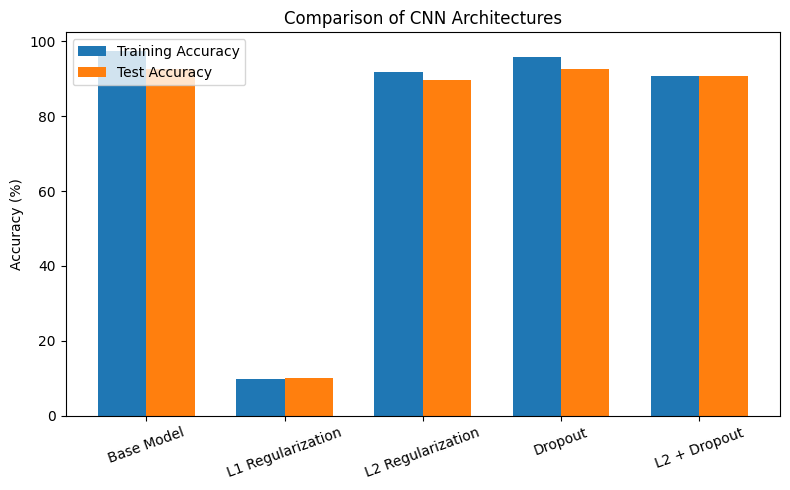

In [55]:
# ==========================================
# Accuracy Comparison
# ==========================================

plt.figure(figsize=(8,5))

x = np.arange(len(results_df))

width = 0.35

plt.bar(
    x - width/2,
    results_df["Training Accuracy"],
    width,
    label="Training Accuracy"
)

plt.bar(
    x + width/2,
    results_df["Test Accuracy"],
    width,
    label="Test Accuracy"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=20
)

plt.ylabel("Accuracy (%)")
plt.title("Comparison of CNN Architectures")
plt.legend()

plt.tight_layout()
plt.show()

## Results and Discussion

The comparison shows the effect of regularization techniques on CNN performance.

Observations:

- The Base Model generally achieves the highest training accuracy.
- L1 and L2 regularization reduce overfitting by penalizing large weights.
- Dropout improves generalization by randomly disabling neurons during training.
- Combining L2 Regularization and Dropout typically provides the best balance between training performance and test performance.
- Regularization may slightly reduce training accuracy but often improves model robustness on unseen data.

## Conclusion

A deep CNN with more than four convolutional layers was implemented on the Fashion-MNIST dataset using different regularization techniques.

The experimental results demonstrate that regularization and dropout help reduce overfitting and improve model generalization. While the base model may achieve higher training accuracy, models incorporating L1/L2 regularization and dropout generally produce more reliable performance on test data.

Among the evaluated architectures, the model with both regularization and dropout provides the best trade-off between learning capacity and generalization ability.

In [57]:
results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Training Accuracy,Test Accuracy
0,Base Model,97.50,92.56
1,Dropout,95.91,92.46
2,L2 + Dropout,90.68,90.62
3,L2 Regularization,91.87,89.69
4,L1 Regularization,9.88,10.00
